# Placement Comparison Analysis
This notebook analyzes the LLM-as-a-judge pairwise comparisons between Semantic placement and static baselines (First, Middle, Last).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

df = pd.read_csv('../data/evaluation/placement_comparison_scores.csv')
df.head()

,query_id,query,ad_id,pos_1,pos_2,winner_pos,confidence,is_swapped
0,0000ab8b-213b-454d-9f0a-44add9f688ce,Who are the Members of le sserafim\n\nAnd what...,Arts & Entertainment / Movies + Science Fictio...,semantic,first,semantic,high,False
1,0000ab8b-213b-454d-9f0a-44add9f688ce,Who are the Members of le sserafim\n\nAnd what...,Arts & Entertainment / Movies + Science Fictio...,first,semantic,first,high,True
2,0000ab8b-213b-454d-9f0a-44add9f688ce,Who are the Members of le sserafim\n\nAnd what...,Arts & Entertainment / Movies + Science Fictio...,semantic,middle,semantic,high,False
3,0000ab8b-213b-454d-9f0a-44add9f688ce,Who are the Members of le sserafim\n\nAnd what...,Arts & Entertainment / Movies + Science Fictio...,middle,semantic,middle,high,True
4,0000ab8b-213b-454d-9f0a-44add9f688ce,Who are the Members of le sserafim\n\nAnd what...,Arts & Entertainment / Movies + Science Fictio...,semantic,last,semantic,high,False


## 1. Overall Win Rate of Semantic Placement

/tmp/ipykernel_2945131/2076027034.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=win_rates, x='baseline_pos', y='semantic_won', palette='viridis')


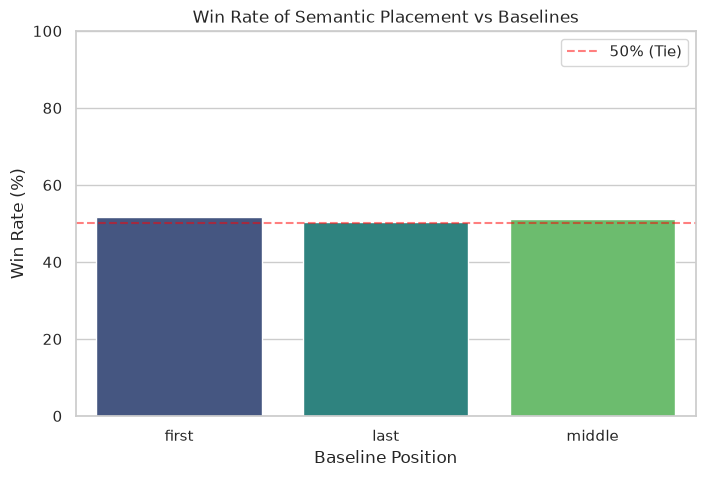

,baseline_pos,semantic_won
0,first,51.615202
1,last,50.380078
2,middle,51.080846


In [2]:
def get_baseline(row):
    return row['pos_2'] if row['pos_1'] == 'semantic' else row['pos_1']

df['baseline_pos'] = df.apply(get_baseline, axis=1)
df['semantic_won'] = df['winner_pos'] == 'semantic'

win_rates = df.groupby('baseline_pos')['semantic_won'].mean().reset_index()
win_rates['semantic_won'] = win_rates['semantic_won'] * 100

plt.figure(figsize=(8, 5))
sns.barplot(data=win_rates, x='baseline_pos', y='semantic_won', palette='viridis')
plt.title('Win Rate of Semantic Placement vs Baselines')
plt.ylabel('Win Rate (%)')
plt.xlabel('Baseline Position')
plt.ylim(0, 100)
plt.axhline(50, color='red', linestyle='--', alpha=0.5, label='50% (Tie)')
plt.legend()
plt.show()

display(win_rates)

## 2. Consistency Analysis (Swapped Pairs)
Check if the LLM judge was consistent in its choice regardless of the order the responses were presented.

/tmp/ipykernel_2945131/826798475.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=consistency_rate.index, y=consistency_rate.values, palette='coolwarm')


Consistency Rate by Baseline:
baseline_pos
first      6.080760
last       3.341516
middle    11.774487
Name: consistent, dtype: float64


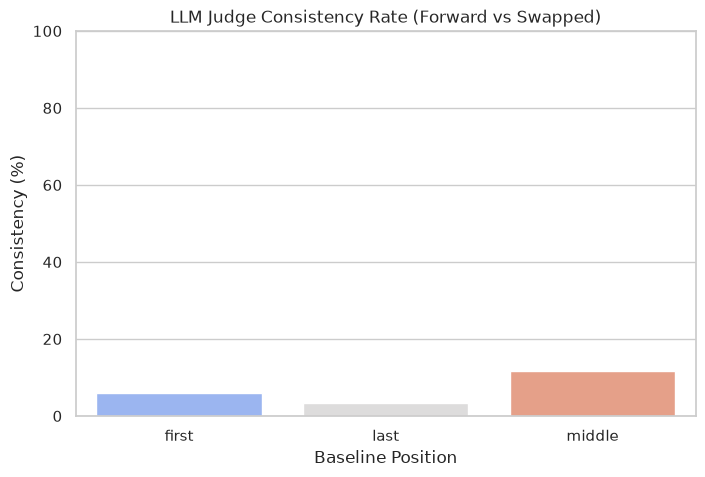

In [3]:
# Group by query_id, ad_id, and baseline_pos to find pairs of forward/swapped evaluations
pivot_df = df.pivot(index=['query_id', 'ad_id', 'baseline_pos'], columns='is_swapped', values='winner_pos').reset_index()
pivot_df = pivot_df.dropna(subset=[False, True])

pivot_df['consistent'] = pivot_df[False] == pivot_df[True]

consistency_rate = pivot_df.groupby('baseline_pos')['consistent'].mean() * 100
print("Consistency Rate by Baseline:")
print(consistency_rate)

plt.figure(figsize=(8, 5))
sns.barplot(x=consistency_rate.index, y=consistency_rate.values, palette='coolwarm')
plt.title('LLM Judge Consistency Rate (Forward vs Swapped)')
plt.ylabel('Consistency (%)')
plt.xlabel('Baseline Position')
plt.ylim(0, 100)
plt.show()

## 3. Win Rate by Confidence Level

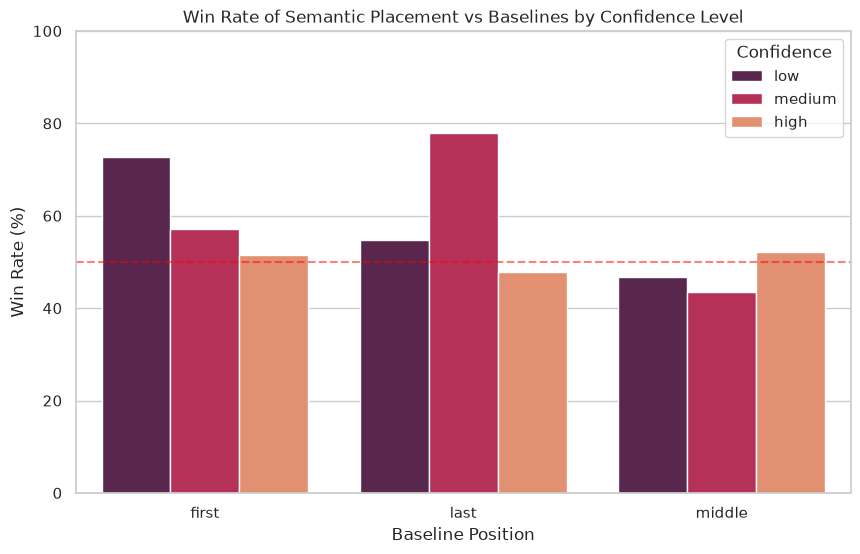

In [4]:
conf_win_rates = df.groupby(['baseline_pos', 'confidence'])['semantic_won'].mean().reset_index()
conf_win_rates['semantic_won'] = conf_win_rates['semantic_won'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(data=conf_win_rates, x='baseline_pos', y='semantic_won', hue='confidence', palette='rocket', hue_order=['low', 'medium', 'high'])
plt.title('Win Rate of Semantic Placement vs Baselines by Confidence Level')
plt.ylabel('Win Rate (%)')
plt.xlabel('Baseline Position')
plt.ylim(0, 100)
plt.legend(title='Confidence')
plt.axhline(50, color='red', linestyle='--', alpha=0.5)
plt.show()